In [1]:
from pathlib import Path
import re
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import wfdb

warnings.filterwarnings("ignore")

In [2]:
PROJECT_DIR = Path.cwd()

DATASET_DIR = PROJECT_DIR / "ptb-diagnostic-ecg-database-1.0.0"

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Dataset directory exists:", DATASET_DIR.exists())

Project directory: d:\HUST\ET4248E - Học máy trong y tế\Final Project
Dataset directory exists: True


In [4]:
# =========================
# VISUAL STYLE
# =========================

PURPLE_MAIN = "#C599B6"
PURPLE_DARK = "#8A5A78"
PURPLE_MID = "#B77FA0"
PURPLE_LIGHT = "#E8D3DF"
PURPLE_VERY_LIGHT = "#F5EAF1"
GRAY = "#6B6B6B"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [5]:
def save_bar_plot(counts, title, xlabel, ylabel, output_path, rotation=0):
    plt.figure(figsize=(8, 5))
    bars = plt.bar(counts.index.astype(str), counts.values, color=PURPLE_MAIN, edgecolor=PURPLE_DARK)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right" if rotation != 0 else "center")
    plt.grid(axis="y", alpha=0.25)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            str(int(height)),
            ha="center",
            va="bottom",
            fontsize=10,
            color="black"
        )

    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()


def save_horizontal_bar_plot(counts, title, xlabel, ylabel, output_path, top_n=None):
    if top_n is not None:
        counts = counts.head(top_n)

    counts = counts.sort_values(ascending=True)

    plt.figure(figsize=(9, max(5, 0.35 * len(counts))))
    bars = plt.barh(counts.index.astype(str), counts.values, color=PURPLE_MAIN, edgecolor=PURPLE_DARK)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(axis="x", alpha=0.25)

    for bar in bars:
        width = bar.get_width()
        plt.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            str(int(width)),
            va="center",
            ha="left",
            fontsize=9,
            color="black"
        )

    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()


def save_histogram(data, title, xlabel, ylabel, output_path, bins=30):
    plt.figure(figsize=(8, 5))
    plt.hist(data.dropna(), bins=bins, color=PURPLE_MAIN, edgecolor=PURPLE_DARK)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()

In [6]:
hea_files = sorted(DATASET_DIR.glob("patient*/s*.hea"))

print("Number of header files found:", len(hea_files))

for path in hea_files[:5]:
    print(path.relative_to(PROJECT_DIR))

Number of header files found: 549
ptb-diagnostic-ecg-database-1.0.0\patient001\s0010_re.hea
ptb-diagnostic-ecg-database-1.0.0\patient001\s0014lre.hea
ptb-diagnostic-ecg-database-1.0.0\patient001\s0016lre.hea
ptb-diagnostic-ecg-database-1.0.0\patient002\s0015lre.hea
ptb-diagnostic-ecg-database-1.0.0\patient003\s0017lre.hea


In [7]:
def clean_text(x):
    if x is None:
        return ""
    return str(x).strip()


def normalize_label(x):
    x = clean_text(x)
    x = x.replace("_", " ")
    x = re.sub(r"\s+", " ", x)
    return x.strip()


def clean_key(key):
    key = str(key).strip()
    key = key.replace("<", "").replace(">", "")
    key = key.lower()
    key = key.replace(" ", "_")
    key = key.replace("-", "_")
    key = re.sub(r"_+", "_", key)
    return key


def parse_header_comments(comments):
    """
    Parse WFDB header comments into a dictionary.
    PTB comments may use formats such as:
    <age>: 81
    <sex>: female
    <reason for admission>: Myocardial infarction
    <infarction localization>: anterior
    """
    fields = {}

    for comment in comments:
        comment = clean_text(comment)

        if ":" in comment:
            key, value = comment.split(":", 1)
            key = clean_key(key)
            value = normalize_label(value)
            fields[key] = value

    return fields


def extract_reason_for_admission(fields, comments):
    candidate_keys = [
        "reason_for_admission",
        "reason",
        "diagnosis",
        "diagnoses",
        "diagnostic_class"
    ]

    for key in candidate_keys:
        if key in fields and fields[key] != "":
            value = fields[key]
            if "myocardial infarction" in value.lower():
                return "Myocardial infarction"
            if "healthy control" in value.lower():
                return "Healthy control"
            return value

    full_text = " ".join([str(c) for c in comments]).lower()

    if "myocardial infarction" in full_text:
        return "Myocardial infarction"
    if "healthy control" in full_text:
        return "Healthy control"

    return "n/a"


def extract_raw_localization(fields, comments):
    candidate_keys = [
        "infarction_localization",
        "infarction_location",
        "localization",
        "location"
    ]

    for key in candidate_keys:
        if key in fields and fields[key] != "":
            return fields[key].lower().strip()

    full_text = " ".join([str(c) for c in comments]).lower()

    # Try to extract text inside parentheses after myocardial infarction
    match = re.search(r"myocardial infarction\s*\((.*?)\)", full_text)
    if match:
        return match.group(1).strip()

    # Fallback keyword detection
    localization_keywords = [
        "antero-septal",
        "antero-lateral",
        "infero-lateral",
        "infero-postero-lateral",
        "infero-poster-lateral",
        "posterior",
        "anterior",
        "inferior",
        "lateral"
    ]

    found = []
    for keyword in localization_keywords:
        if keyword in full_text:
            found.append(keyword)

    if len(found) > 0:
        return "+".join(found)

    return ""


def parse_one_record_header(hea_path):
    record_path_no_ext = hea_path.with_suffix("")
    header = wfdb.rdheader(str(record_path_no_ext))

    comments = header.comments
    fields = parse_header_comments(comments)

    patient_id = hea_path.parent.name
    record_id = hea_path.stem
    record_path = str(record_path_no_ext.relative_to(PROJECT_DIR))

    reason_for_admission = extract_reason_for_admission(fields, comments)
    raw_localization = extract_raw_localization(fields, comments)

    age = fields.get("age", "")
    sex = fields.get("sex", "")

    row = {
        "patient_id": patient_id,
        "record_id": record_id,
        "record_path": record_path,
        "age": age,
        "sex": sex,
        "reason_for_admission": reason_for_admission,
        "raw_localization": raw_localization,
        "fs": header.fs,
        "n_sig": header.n_sig,
        "sig_len": header.sig_len,
        "duration_sec": header.sig_len / header.fs if header.fs else np.nan,
        "comments_text": " | ".join(comments)
    }

    return row

In [22]:
# =========================
# IMPROVED LOCALIZATION PARSING
# =========================
# This is only used for EDA and task justification.
# The main project target remains binary MI detection.

def extract_field_from_comments_text(text, field_name):
    """
    Extract exact value after a field such as:
    'Acute infarction (localization): anterior'
    from the comments_text string.
    """
    if pd.isna(text):
        return ""

    parts = str(text).split(" | ")

    for part in parts:
        if ":" in part:
            key, value = part.split(":", 1)
            key_clean = key.strip().lower()
            value_clean = value.strip().lower()

            if key_clean == field_name.lower():
                return value_clean

    return ""


labels_df["acute_localization"] = labels_df["comments_text"].apply(
    lambda x: extract_field_from_comments_text(x, "Acute infarction (localization)")
)

labels_df["former_localization"] = labels_df["comments_text"].apply(
    lambda x: extract_field_from_comments_text(x, "Former infarction (localization)")
)

# Clean unclear or non-informative labels
def clean_localization_value(x):
    x = str(x).lower().strip()

    if x in ["", "no", "n/a", "nan", "unknown"]:
        return ""

    # remove uncertainty marker
    x = x.replace("?", "").strip()

    # fix common typo/variant if needed
    x = x.replace("infero-latera", "infero-lateral")

    return x


labels_df["acute_localization_clean"] = labels_df["acute_localization"].apply(clean_localization_value)
labels_df["former_localization_clean"] = labels_df["former_localization"].apply(clean_localization_value)

print("Acute localization distribution:")
display(labels_df[labels_df["mi_detected"] == 1]["acute_localization_clean"].replace("", np.nan).value_counts(dropna=True).head(30))

print("\nFormer localization distribution:")
display(labels_df[labels_df["mi_detected"] == 1]["former_localization_clean"].replace("", np.nan).value_counts(dropna=True).head(30))

display(
    labels_df[
        ["patient_id", "record_id", "reason_for_admission",
         "acute_localization_clean", "former_localization_clean"]
    ].head(20)
)

Acute localization distribution:


acute_localization_clean
inferior                  89
antero-septal             77
infero-laterall           53
anterior                  47
antero-lateral            43
infero-postero-lateral    16
postero-lateral            5
posterior                  4
infero-lateral             3
infero-poster-lateral      3
lateral                    3
antero-septo-lateral       2
infero-posterior           1
Name: count, dtype: int64


Former localization distribution:


former_localization_clean
anterior                              28
inferior                              26
antero-lateral                         6
antero-septal                          5
infero-posterior                       5
postero-lateral                        4
infero-laterall                        4
anterior (1), inferior (2)             2
inferior (1+2)                         2
anterior (1), anterior (2)             1
infero-postero-lateral                 1
infero-posterior (1), inferior (2)     1
Name: count, dtype: int64

,patient_id,record_id,reason_for_admission,acute_localization_clean,former_localization_clean
0,patient001,s0010_re,Myocardial infarction,infero-lateral,
1,patient001,s0014lre,Myocardial infarction,infero-lateral,
2,patient001,s0016lre,Myocardial infarction,infero-lateral,
3,patient002,s0015lre,Myocardial infarction,anterior,
4,patient003,s0017lre,Myocardial infarction,infero-postero-lateral,
5,patient004,s0020are,Myocardial infarction,antero-septal,
6,patient004,s0020bre,Myocardial infarction,antero-septal,
7,patient005,s0021are,Myocardial infarction,anterior,
8,patient005,s0021bre,Myocardial infarction,anterior,
9,patient005,s0025lre,Myocardial infarction,anterior,


In [23]:
rows = []

for hea_path in hea_files:
    try:
        row = parse_one_record_header(hea_path)
        rows.append(row)
    except Exception as e:
        print("Failed:", hea_path, e)

labels_df = pd.DataFrame(rows)

print("Labels dataframe shape:", labels_df.shape)
display(labels_df.head())

print("\nColumns:")
print(labels_df.columns.tolist())

Labels dataframe shape: (549, 12)


,patient_id,record_id,record_path,age,sex,reason_for_admission,raw_localization,fs,n_sig,sig_len,duration_sec,comments_text
0,patient001,s0010_re,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,81,female,Myocardial infarction,inferior,1000,15,38400,38.4,age: 81 | sex: female | ECG date: 01/10/1990 |...
1,patient001,s0014lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,81,female,Myocardial infarction,inferior,1000,15,115200,115.2,age: 81 | sex: female | ECG date: 17/10/1990 |...
2,patient001,s0016lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,81,female,Myocardial infarction,inferior,1000,15,115200,115.2,age: 81 | sex: female | ECG date: 18/10/1990 |...
3,patient002,s0015lre,ptb-diagnostic-ecg-database-1.0.0\patient002\s...,58,female,Myocardial infarction,anterior,1000,15,115200,115.2,age: 58 | sex: female | ECG date: 17/10/1990 |...
4,patient003,s0017lre,ptb-diagnostic-ecg-database-1.0.0\patient003\s...,63,male,Myocardial infarction,infero-lateral+infero-postero-lateral+posterio...,1000,15,115200,115.2,age: 63 | sex: male | ECG date: 18/10/1990 | D...



Columns:
['patient_id', 'record_id', 'record_path', 'age', 'sex', 'reason_for_admission', 'raw_localization', 'fs', 'n_sig', 'sig_len', 'duration_sec', 'comments_text']


In [24]:
labels_df["reason_for_admission"] = labels_df["reason_for_admission"].fillna("n/a")

labels_df["mi_detected"] = labels_df["reason_for_admission"].apply(
    lambda x: 1 if str(x).strip().lower() == "myocardial infarction" else 0
)

labels_df["healthy_control"] = labels_df["reason_for_admission"].apply(
    lambda x: 1 if str(x).strip().lower() == "healthy control" else 0
)

print("Reason for admission distribution:")
display(labels_df["reason_for_admission"].value_counts())

print("\nMI detected distribution:")
display(labels_df["mi_detected"].value_counts())

print("\nHealthy control distribution:")
display(labels_df["healthy_control"].value_counts())

Reason for admission distribution:


reason_for_admission
Myocardial infarction     368
Healthy control            80
n/a                        27
Cardiomyopathy             17
Bundle branch block        17
Dysrhythmia                16
Hypertrophy                 7
Valvular heart disease      6
Myocarditis                 4
Stable angina               2
Heart failure (NYHA 2)      1
Heart failure (NYHA 3)      1
Heart failure (NYHA 4)      1
Palpitation                 1
Unstable angina             1
Name: count, dtype: int64


MI detected distribution:


mi_detected
1    368
0    181
Name: count, dtype: int64


Healthy control distribution:


healthy_control
0    469
1     80
Name: count, dtype: int64

In [25]:
dataset_summary = {
    "n_records": labels_df["record_id"].nunique(),
    "n_patients": labels_df["patient_id"].nunique(),
    "n_mi_records": int(labels_df["mi_detected"].sum()),
    "n_healthy_records": int(labels_df["healthy_control"].sum()),
    "n_other_records": int(((labels_df["mi_detected"] == 0) & (labels_df["healthy_control"] == 0)).sum()),
    "mean_duration_sec": float(labels_df["duration_sec"].mean()),
    "median_duration_sec": float(labels_df["duration_sec"].median()),
    "min_duration_sec": float(labels_df["duration_sec"].min()),
    "max_duration_sec": float(labels_df["duration_sec"].max())
}

dataset_summary_df = pd.DataFrame([dataset_summary])
display(dataset_summary_df)

summary_path = TABLE_DIR / "notebook1_dataset_summary.csv"
dataset_summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")

print("Saved summary to:", summary_path)

,n_records,n_patients,n_mi_records,n_healthy_records,n_other_records,mean_duration_sec,median_duration_sec,min_duration_sec,max_duration_sec
0,549,290,368,80,101,108.596457,115.2,32.0,120.012


Saved summary to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook1_dataset_summary.csv


# Initial EDA

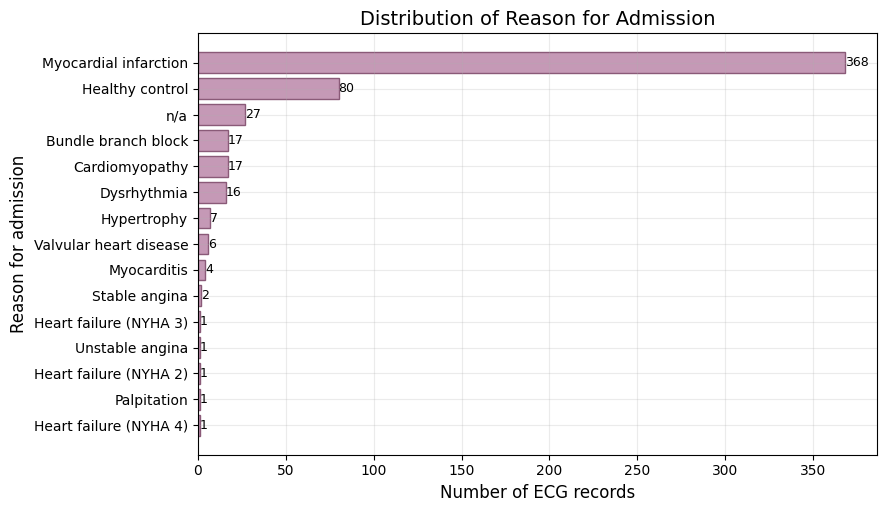

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook1_reason_for_admission_distribution.png


In [26]:
reason_counts = labels_df["reason_for_admission"].value_counts()

fig_path = FIGURE_DIR / "notebook1_reason_for_admission_distribution.png"

save_horizontal_bar_plot(
    reason_counts,
    title="Distribution of Reason for Admission",
    xlabel="Number of ECG records",
    ylabel="Reason for admission",
    output_path=fig_path,
    top_n=15
)

print("Saved figure to:", fig_path)

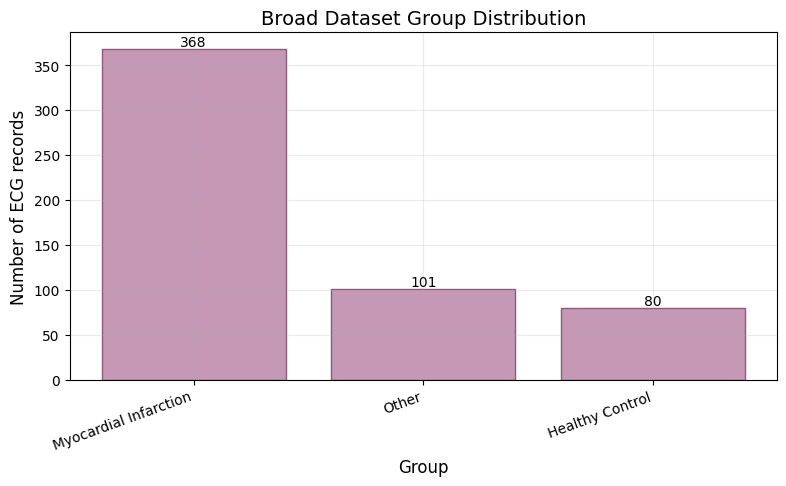

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook1_broad_group_distribution.png


In [27]:
labels_df["broad_group"] = np.select(
    [
        labels_df["mi_detected"] == 1,
        labels_df["healthy_control"] == 1
    ],
    [
        "Myocardial Infarction",
        "Healthy Control"
    ],
    default="Other"
)

broad_counts = labels_df["broad_group"].value_counts()

fig_path = FIGURE_DIR / "notebook1_broad_group_distribution.png"

save_bar_plot(
    broad_counts,
    title="Broad Dataset Group Distribution",
    xlabel="Group",
    ylabel="Number of ECG records",
    output_path=fig_path,
    rotation=20
)

print("Saved figure to:", fig_path)

Records per patient summary:


count    290.000000
mean       1.893103
std        1.258447
min        1.000000
25%        1.000000
50%        1.000000
75%        3.000000
max        7.000000
Name: record_id, dtype: float64


Top patients with most records:


patient_id
patient180    7
patient093    5
patient005    5
patient233    5
patient024    4
patient023    4
patient032    4
patient031    4
patient030    4
patient046    4
patient041    4
patient040    4
patient044    4
patient048    4
patient051    4
patient054    4
patient035    4
patient065    4
patient042    4
patient034    4
Name: record_id, dtype: int64

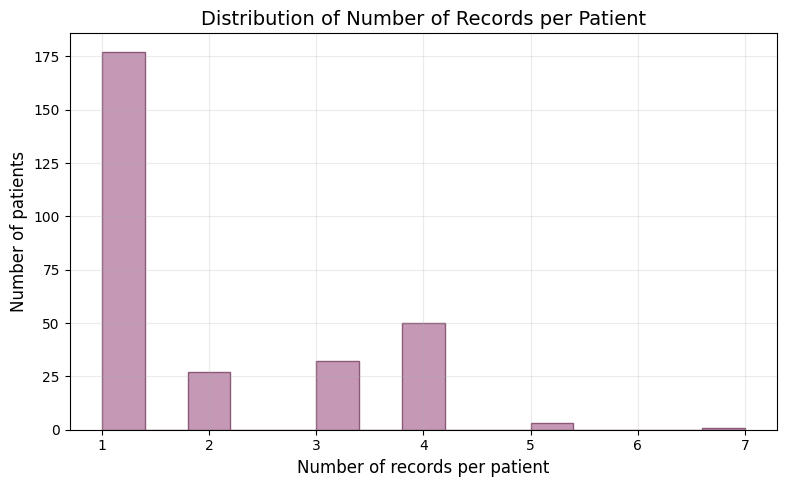

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook1_records_per_patient_distribution.png


In [28]:
records_per_patient = (
    labels_df
    .groupby("patient_id")["record_id"]
    .nunique()
    .sort_values(ascending=False)
)

print("Records per patient summary:")
display(records_per_patient.describe())

print("\nTop patients with most records:")
display(records_per_patient.head(20))

fig_path = FIGURE_DIR / "notebook1_records_per_patient_distribution.png"

save_histogram(
    records_per_patient,
    title="Distribution of Number of Records per Patient",
    xlabel="Number of records per patient",
    ylabel="Number of patients",
    output_path=fig_path,
    bins=15
)

print("Saved figure to:", fig_path)

patient_group
Myocardial Infarction    148
Other                     90
Healthy Control           52
Name: count, dtype: int64

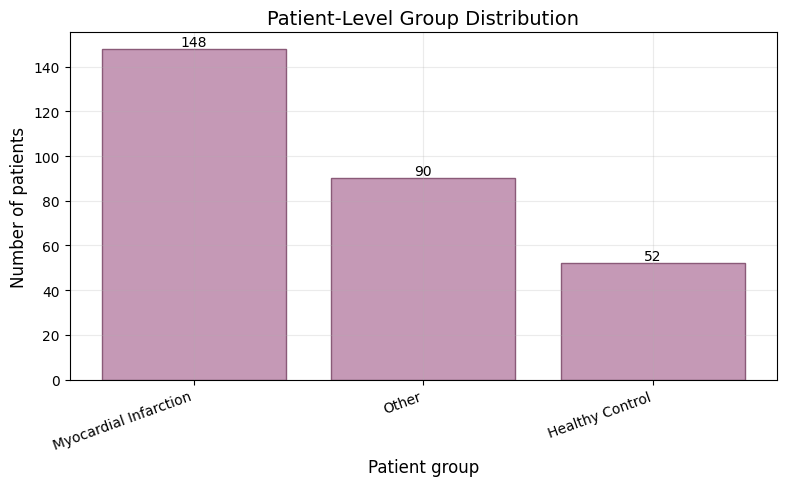

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook1_patient_group_distribution.png


In [29]:
patient_level_df = (
    labels_df
    .groupby("patient_id")
    .agg(
        n_records=("record_id", "nunique"),
        has_mi=("mi_detected", "max"),
        has_healthy=("healthy_control", "max")
    )
    .reset_index()
)

patient_level_df["patient_group"] = np.select(
    [
        patient_level_df["has_mi"] == 1,
        patient_level_df["has_healthy"] == 1
    ],
    [
        "Myocardial Infarction",
        "Healthy Control"
    ],
    default="Other"
)

patient_group_counts = patient_level_df["patient_group"].value_counts()

display(patient_group_counts)

fig_path = FIGURE_DIR / "notebook1_patient_group_distribution.png"

save_bar_plot(
    patient_group_counts,
    title="Patient-Level Group Distribution",
    xlabel="Patient group",
    ylabel="Number of patients",
    output_path=fig_path,
    rotation=20
)

print("Saved figure to:", fig_path)

In [30]:
detection_df = labels_df[
    (labels_df["mi_detected"] == 1) |
    (labels_df["healthy_control"] == 1)
].copy()

print("Detection dataset shape:", detection_df.shape)

print("\nRecord-level class distribution:")
display(detection_df["mi_detected"].value_counts())

print("\nPatient-level class distribution:")
display(
    detection_df
    .groupby("patient_id")["mi_detected"]
    .agg(lambda x: x.mode().iloc[0])
    .value_counts()
)

detection_output_path = PROCESSED_DIR / "ptb_detection_records.csv"
detection_df.to_csv(detection_output_path, index=False, encoding="utf-8-sig")

print("Saved detection dataset to:")
print(detection_output_path)

Detection dataset shape: (448, 15)

Record-level class distribution:


mi_detected
1    368
0     80
Name: count, dtype: int64


Patient-level class distribution:


mi_detected
1    148
0     52
Name: count, dtype: int64

Saved detection dataset to:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\data\processed\ptb_detection_records.csv


In [31]:
detection_df = labels_df[
    (labels_df["mi_detected"] == 1) |
    (labels_df["healthy_control"] == 1)
].copy()

print("Detection dataset shape:", detection_df.shape)

print("\nRecord-level class distribution:")
display(detection_df["mi_detected"].value_counts())

print("\nPatient-level class distribution:")
display(
    detection_df
    .groupby("patient_id")["mi_detected"]
    .agg(lambda x: x.mode().iloc[0])
    .value_counts()
)

detection_output_path = PROCESSED_DIR / "ptb_detection_records.csv"
detection_df.to_csv(detection_output_path, index=False, encoding="utf-8-sig")

print("Saved detection dataset to:")
print(detection_output_path)

Detection dataset shape: (448, 15)

Record-level class distribution:


mi_detected
1    368
0     80
Name: count, dtype: int64


Patient-level class distribution:


mi_detected
1    148
0     52
Name: count, dtype: int64

Saved detection dataset to:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\data\processed\ptb_detection_records.csv


In [32]:
task_definition = {
    "project_title": "Interpretable Machine Learning Analysis of ECG Lead Contributions and Lead Combinations for Myocardial Infarction Detection",
    "main_task": "Binary myocardial infarction detection",
    "target_variable": "mi_detected",
    "positive_class": "Myocardial infarction",
    "negative_class": "Healthy control",
    "secondary_analysis": "ECG lead contribution and lead combination analysis",
    "reason_for_not_using_single_label_localization": (
        "Initial EDA showed that PTB MI localization annotations contain overlapping "
        "multi-region labels such as antero-lateral, infero-lateral, and infero-postero-lateral. "
        "Forcing these labels into mutually exclusive single-class localization targets may introduce "
        "label noise and reduce clinical interpretability. Therefore, this project focuses on the cleaner "
        "binary MI detection task and interpretable lead contribution analysis."
    )
}

task_definition_path = TABLE_DIR / "notebook1_task_definition.json"

with open(task_definition_path, "w", encoding="utf-8") as f:
    json.dump(task_definition, f, indent=4, ensure_ascii=False)

print("Saved task definition to:")
print(task_definition_path)

print(json.dumps(task_definition, indent=4, ensure_ascii=False))

Saved task definition to:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook1_task_definition.json
{
    "project_title": "Interpretable Machine Learning Analysis of ECG Lead Contributions and Lead Combinations for Myocardial Infarction Detection",
    "main_task": "Binary myocardial infarction detection",
    "target_variable": "mi_detected",
    "positive_class": "Myocardial infarction",
    "negative_class": "Healthy control",
    "secondary_analysis": "ECG lead contribution and lead combination analysis",
    "reason_for_not_using_single_label_localization": "Initial EDA showed that PTB MI localization annotations contain overlapping multi-region labels such as antero-lateral, infero-lateral, and infero-postero-lateral. Forcing these labels into mutually exclusive single-class localization targets may introduce label noise and reduce clinical interpretability. Therefore, this project focuses on the cleaner binary MI detection task and interpretable lead cont